# Unfreeze classifier + layer 10 + layer 11 dan Belum Format BIO (NER)

# Install & Import Library


In [3]:
!pip install -q transformers datasets accelerate seqeval

In [4]:
import torch
import pandas as pd
import numpy as np
from datasets import Dataset, DatasetDict, Features, Sequence, Value
from sklearn.model_selection import train_test_split
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification
)
from seqeval.metrics import f1_score, precision_score, recall_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import collections

2025-11-27 03:48:12.113110: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764215292.318010      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764215292.381505      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

# Load Data

In [5]:
import os
if os.path.exists('/kaggle/input'):
    path = "/kaggle/input/datasetsinggalang/SINGGALANG_oversampled.tsv"
else:
    # Path lokal atau alternatif
    path = "./data/SINGGALANG_oversampled.tsv"

df = pd.read_csv(
    path,
    sep="\t",
    header=None,
    skiprows=[0],        # membuang baris pertama ("0 1")
    names=["token", "label"],
    dtype=str
)

MAX_LEN = 128
tokens = df["token"].tolist()
labels = df["label"].tolist()

sentences = []
sentence_labels = []

for i in range(0, len(tokens), MAX_LEN):
    sentences.append(tokens[i:i+MAX_LEN])
    sentence_labels.append(labels[i:i+MAX_LEN])

print("Total rows:", len(df))
print("Total sequences:", len(sentences))


Total rows: 5360092
Total sequences: 41876


# Mapping label

In [6]:
label_list = sorted(df["label"].unique())
label_to_id = {l: i for i, l in enumerate(label_list)}
id_to_label = {i: l for l, i in label_to_id.items()}

label_ids = [[label_to_id[l] for l in seq] for seq in sentence_labels]

print("Labels:", label_list)
print("Mapping:", label_to_id)


Labels: ['O', 'Organisation', 'Person', 'Place']
Mapping: {'O': 0, 'Organisation': 1, 'Person': 2, 'Place': 3}


In [7]:
indices = list(range(len(sentences)))

train_idx, val_idx = train_test_split(
    indices, test_size=0.2, shuffle=True, random_state=42
)

train_data = {
    "tokens": [[str(tok) for tok in sentences[i]] for i in train_idx],
    "ner_tags": [[int(x) for x in label_ids[i]] for i in train_idx],
}

val_data = {
    "tokens": [[str(tok) for tok in sentences[i]] for i in val_idx],
    "ner_tags": [[int(x) for x in label_ids[i]] for i in val_idx],
}

features = Features({
    "tokens": Sequence(Value("string")),
    "ner_tags": Sequence(Value("int64"))
})

train_dataset = Dataset.from_dict(train_data, features=features)
val_dataset   = Dataset.from_dict(val_data, features=features)

dataset_dict = DatasetDict({
    "train": train_dataset,
    "validation": val_dataset
})

print(dataset_dict)


DatasetDict({
    train: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 33500
    })
    validation: Dataset({
        features: ['tokens', 'ner_tags'],
        num_rows: 8376
    })
})


# Load Model

In [8]:
model_name = "ChristopherA08/IndoELECTRA"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_and_align_labels(batch):
    tokenized = tokenizer(
        batch["tokens"],
        is_split_into_words=True,
        truncation=True,
        padding=False
    )

    aligned_labels = []

    for i, labels in enumerate(batch["ner_tags"]):
        word_ids = tokenized.word_ids(batch_index=i)
        previous = None
        label_ids_seq = []

        for w in word_ids:
            if w is None:
                label_ids_seq.append(-100)
            elif w != previous:
                label_ids_seq.append(labels[w])
            else:
                label_ids_seq.append(-100)
            previous = w

        aligned_labels.append(label_ids_seq)

    tokenized["labels"] = aligned_labels
    return tokenized

tokenized_datasets = dataset_dict.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=["tokens", "ner_tags"]
)


config.json:   0%|          | 0.00/467 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/33500 [00:00<?, ? examples/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Map:   0%|          | 0/8376 [00:00<?, ? examples/s]

In [11]:
model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    num_labels=len(label_list),
    label2id=label_to_id,
    id2label=id_to_label,
    ignore_mismatched_sizes=True
)

model.resize_token_embeddings(len(tokenizer))

for name, param in model.named_parameters():
    if "classifier" not in name:
        param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
total = trainable + frozen
model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    num_labels=len(label_list),
    label2id=label_to_id,
    id2label=id_to_label,
    ignore_mismatched_sizes=True
)

model.resize_token_embeddings(len(tokenizer))

# Freeze semua parameter terlebih dahulu
for param in model.parameters():
    param.requires_grad = False

# Unfreeze classifier (MLP head)
for param in model.classifier.parameters():
    param.requires_grad = True

# Unfreeze 2 layer terakhir dari encoder
# Untuk ELECTRA, layer ada di model.electra.encoder.layer
num_layers = len(model.electra.encoder.layer)
for i in range(num_layers - 2, num_layers):  # 2 layer terakhir
    for param in model.electra.encoder.layer[i].parameters():
        param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)
total = trainable + frozen

print("Total parameters:", total)
print("Trainable parameters:", trainable)
print("Frozen parameters:", frozen)
print(f"Total layers: {num_layers}")
print(f"Unfrozen layers: classifier + layer {num_layers-2} + layer {num_layers-1}")
print("Total parameters:", total)
print("Trainable parameters:", trainable)
print("Frozen parameters:", frozen)


Some weights of ElectraForTokenClassification were not initialized from the model checkpoint at ChristopherA08/IndoELECTRA and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of ElectraForTokenClassification were not initialized from the model checkpoint at ChristopherA08/IndoELECTRA and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Total parameters: 112333828
Trainable parameters: 14178820
Frozen parameters: 98155008
Total layers: 12
Unfrozen layers: classifier + layer 10 + layer 11
Total parameters: 112333828
Trainable parameters: 14178820
Frozen parameters: 98155008


In [15]:
data_collator = DataCollatorForTokenClassification(tokenizer)

def compute_metrics(pred):
    logits, labels = pred
    preds = np.argmax(logits, axis=2)

    true_preds = [
        [id_to_label[p] for p, l in zip(pred_seq, label_seq) if l != -100]
        for pred_seq, label_seq in zip(preds, labels)
    ]

    true_labels = [
        [id_to_label[l] for p, l in zip(pred_seq, label_seq) if l != -100]
        for pred_seq, label_seq in zip(preds, labels)
    ]

    # Hitung accuracy
    correct = sum([p == t for pred_seq, true_seq in zip(true_preds, true_labels) 
                   for p, t in zip(pred_seq, true_seq)])
    total = sum([len(seq) for seq in true_preds])
    accuracy = correct / total if total > 0 else 0

    return {
        "accuracy": accuracy,
        "f1": f1_score(true_labels, true_preds),
        "precision": precision_score(true_labels, true_preds),
        "recall": recall_score(true_labels, true_preds)
    }


# Config Training

In [16]:
training_args = TrainingArguments(
    output_dir="./NER-IndoELECTRA",
    eval_strategy="epoch",
    save_strategy="epoch",
    optim="adamw_torch",
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=4,
    num_train_epochs=12,
    fp16=True,
    learning_rate=5e-4,
    weight_decay=0.01,
    logging_steps=500,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["validation"],
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)


/tmp/ipykernel_47/3978585935.py:19: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


In [17]:
trainer.train()

metrics = trainer.evaluate()
print(metrics)


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.038048,0.984794,0.692905,0.681766,0.704413
2,0.048100,0.036450,0.985654,0.704951,0.699612,0.710373
3,0.048100,0.035967,0.986392,0.707450,0.747791,0.671239
4,0.030000,0.034571,0.986925,0.719337,0.723708,0.715018
5,0.030000,0.035670,0.986619,0.722551,0.702513,0.743766
6,0.024000,0.035410,0.987098,0.722023,0.733735,0.710680
7,0.024000,0.037754,0.987071,0.726014,0.727950,0.724090
8,0.019200,0.038712,0.986984,0.721199,0.722388,0.720014
9,0.019200,0.040997,0.987042,0.722941,0.714041,0.732065
10,0.015400,0.042779,0.987144,0.723676,0.726038,0.721329


/usr/local/lib/python3.11/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: Place seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.11/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: Person seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.11/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: Organisation seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: Place seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.11/d

/usr/local/lib/python3.11/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: Place seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.11/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: Person seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.11/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: Organisation seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))


{'eval_loss': 0.03775399923324585, 'eval_accuracy': 0.9870705736628462, 'eval_f1': 0.7260144561372674, 'eval_precision': 0.7279495990836197, 'eval_recall': 0.7240895744774092, 'eval_runtime': 96.3555, 'eval_samples_per_second': 86.928, 'eval_steps_per_second': 1.36, 'epoch': 12.0}


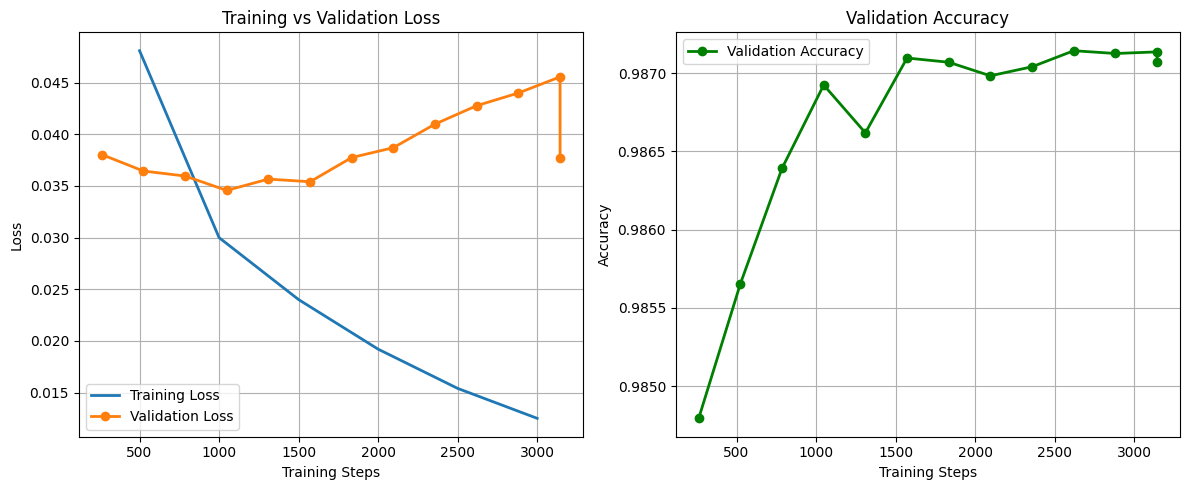

In [18]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_steps = []
train_loss = []
eval_steps = []
eval_loss = []
eval_accuracy = []   # akan tetap kosong kalau kamu tidak menghitung accuracy

for entry in log_history:

    # Training loss dicatat sebagai {"loss": ..., "step": ...}
    if "loss" in entry and "step" in entry:
        train_steps.append(entry["step"])
        train_loss.append(entry["loss"])

    # Validation loss dan accuracy dicatat sebagai {"eval_loss": ..., "step": ...}
    if "eval_loss" in entry and "step" in entry:
        eval_steps.append(entry["step"])
        eval_loss.append(entry["eval_loss"])

        if "eval_accuracy" in entry:
            eval_accuracy.append(entry["eval_accuracy"])

plt.figure(figsize=(12,5))

# Plot Loss
plt.subplot(1,2,1)
plt.plot(train_steps, train_loss, label="Training Loss", linewidth=2)
plt.plot(eval_steps, eval_loss, label="Validation Loss", linewidth=2, marker='o')
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

# Plot Accuracy (jika ada)
plt.subplot(1,2,2)
if len(eval_accuracy) > 0:
    plt.plot(eval_steps, eval_accuracy, label="Validation Accuracy",
             linewidth=2, marker='o', color='green')
    plt.xlabel("Training Steps")
    plt.ylabel("Accuracy")
    plt.title("Validation Accuracy")
    plt.legend()
    plt.grid(True)
else:
    plt.text(0.5, 0.5, "No accuracy metric found", ha='center')

plt.tight_layout()
plt.show()


# Evaluation

In [21]:
from seqeval.metrics import classification_report, f1_score, precision_score, recall_score
import numpy as np

# Prediksi model di validation set
predictions, label_ids, _ = trainer.predict(tokenized_datasets["validation"])

# Prediksi ID kelas
pred_ids = np.argmax(predictions, axis=2)

true_tags = []
pred_tags = []

# Untuk accuracy
total_tokens = 0
correct_tokens = 0

for pred_seq, true_seq in zip(pred_ids, label_ids):
    seq_true = []
    seq_pred = []

    for t, p in zip(true_seq, pred_seq):

        # Abaikan token bertanda -100
        if t == -100:
            continue

        # Hitung accuracy token-level
        total_tokens += 1
        if t == p:
            correct_tokens += 1

        seq_true.append(id_to_label[t])
        seq_pred.append(id_to_label[p])

    true_tags.append(seq_true)
    pred_tags.append(seq_pred)

# Hitung accuracy
accuracy = correct_tokens / total_tokens

# Tampilkan hasil
print("Token-level Accuracy:", accuracy)
print("\nClassification Report (SeqEval):\n")
print(classification_report(true_tags, pred_tags))

# Ringkasan
print("\nSummary Metrics:")
print("F1-score :", f1_score(true_tags, pred_tags))
print("Precision:", precision_score(true_tags, pred_tags))
print("Recall   :", recall_score(true_tags, pred_tags))
print("Accuracy :", accuracy)


Token-level Accuracy: 0.9870705736628462

Classification Report (SeqEval):

              precision    recall  f1-score   support

       erson       0.70      0.60      0.64      7656
        lace       0.74      0.79      0.76     15163

   micro avg       0.73      0.72      0.73     22819
   macro avg       0.72      0.69      0.70     22819
weighted avg       0.73      0.72      0.72     22819


Summary Metrics:
F1-score : 0.7260144561372674
Precision: 0.7279495990836197
Recall   : 0.7240895744774092
Accuracy : 0.9870705736628462


TRUE counts: Counter({'O': 274235, 'Place': 271797, 'Organisation': 267705, 'Person': 258391})
PRED counts: Counter({'O': 275343, 'Place': 272743, 'Organisation': 267306, 'Person': 256736})
Labels used in confusion matrix: ['O', 'Organisation', 'Person', 'Place']


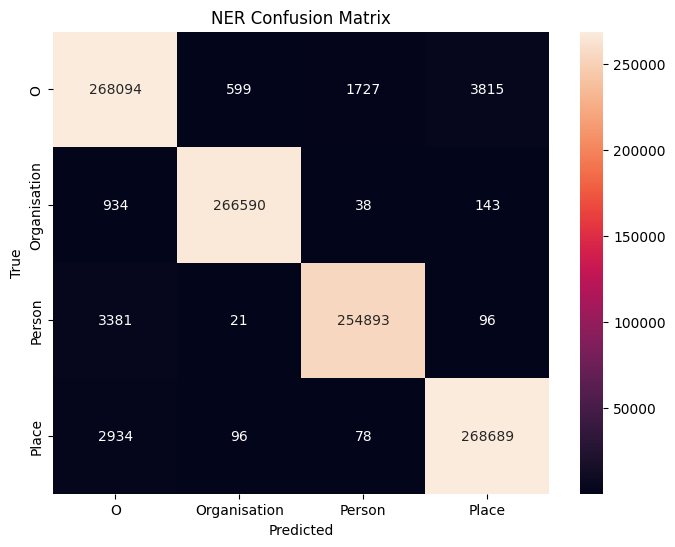

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import collections 

# Flatten true and pred tags
flat_true = [tag for seq in true_tags for tag in seq]
flat_pred = [tag for seq in pred_tags for tag in seq]

print("TRUE counts:", collections.Counter(flat_true))
print("PRED counts:", collections.Counter(flat_pred))

labels_in_true = set(flat_true)
labels_in_pred = set(flat_pred)

valid_labels = sorted(list(labels_in_true.union(labels_in_pred)))

print("Labels used in confusion matrix:", valid_labels)

# Hitung confusion matrix
cm = confusion_matrix(flat_true, flat_pred, labels=valid_labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=valid_labels,
            yticklabels=valid_labels)

plt.title("NER Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
